# Relatório Técnico & Benchmark de Robustez OOD: Detecção de Deepfakes
## Avaliação das 6 Famílias e 7 Modos Espectrais sob Teste Normal vs Teste Difícil
**Pesquisa e Monografia de TCC:** Detecção de Deepfakes e Generalização Fora do Domínio (OOD)  
**Dataset:** Phase 1 Benchmark (Normal Test: ~182k imagens | Difficult Test `test_d`: ~182k imagens com perturbações adversariais e de compressão)  
**Total de Modelos:** 42 configurações $\times$ 5 seeds = 210 redes neurais avaliadas (38,2 milhões de inferências de teste).

---

### Objetivos do Notebook:
1. **Carregamento Completo das 5 Seeds:** Avaliação estocástica e garantia de reprodutibilidade científica (todas as métricas reportadas com **Média $\pm$ Desvio Padrão**).
2. **Comparação Direta:** Teste Normal (IID) versus Teste Difícil (OOD / `test_d`).
3. **Sistema de Atribuição de Notas (Grading Engine):** Critério multicritério de pontuação (0 a 10 e conceitos A+ a F) balanceando capacidade preditiva, robustez sob ruído e estabilidade entre seeds.
4. **Análise de Domínio de Frequência:** Avaliação do impacto real das decomposições e fusões de Fourier (`none`, `concat`, `concat_frequency`, `magnitude`, `frequency_3`, `phase`, `complex`).
5. **Estudo de Explicabilidade (XAI):** Mapeamento atencional e de gradientes nas 5 seeds para amostras reais e falsas.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para publicação acadêmica
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 16

Path('figures').mkdir(parents=True, exist_ok=True)
print("Ambiente configurado e bibliotecas carregadas com sucesso!")


Ambiente configurado e bibliotecas carregadas com sucesso!


---
## 1. Carregamento e Validação dos Dados das 5 Seeds

Os experimentos utilizaram uma bateria fixa de 5 sementes aleatórias (`seed_42, seed_123, seed_2024, seed_7, seed_2025`) para cada uma das 42 configurações (6 famílias $\times$ 7 modos Fourier).


In [2]:
agg_path = Path("tables/benchmark_test_vs_test_d.csv")
seeds_path = Path("tables/results_seed_level.csv")

df_agg = pd.read_csv(agg_path)
df_seeds = pd.read_csv(seeds_path)

print(f"Total de configurações agregadas: {len(df_agg)} (esperado: 42)")
print(f"Total de execuções individuais carregadas: {len(df_seeds)} (esperado: 210)")
print("Sementes presentes:", sorted(df_seeds['seed'].unique().tolist()))


Total de configurações agregadas: 42 (esperado: 42)
Total de execuções individuais carregadas: 210 (esperado: 210)
Sementes presentes: [7, 42, 123, 2024, 2025]


### Tabela Estatística Geral: Média $\pm$ Desvio Padrão (5 Seeds)

Apresentamos a seguir o comparativo ordenado pela **Nota Final (Score)** de cada configuração.


In [3]:
def format_mean_std(mean, std):
    if pd.isna(mean): return "N/A"
    if pd.isna(std): return f"{mean*100:.2f}%"
    return f"{mean*100:.2f} ± {std*100:.2f}%"

df_display = df_agg.copy()
df_display['Test AUC'] = [format_mean_std(m, s) for m, s in zip(df_display['test_auc_mean'], df_display['test_auc_std'])]
df_display['Test ACC'] = [format_mean_std(m, s) for m, s in zip(df_display['test_acc_mean'], df_display['test_acc_std'])]
df_display['Test_d AUC'] = [format_mean_std(m, s) for m, s in zip(df_display['test_d_auc_mean'], df_display['test_d_auc_std'])]
df_display['Test_d ACC'] = [format_mean_std(m, s) for m, s in zip(df_display['test_d_acc_mean'], df_display['test_d_acc_std'])]
df_display['Δ AUC (Queda)'] = [f"{m*100:+.2f}%" if not pd.isna(m) else "N/A" for m in df_display['delta_auc_mean']]

cols_show = ['model_family', 'fourier_mode', 'Test AUC', 'Test ACC', 'Test_d AUC', 'Test_d ACC', 'Δ AUC (Queda)', 'final_score', 'grade_concept']
df_display_ranked = df_display[cols_show].rename(columns={
    'model_family': 'Família',
    'fourier_mode': 'Modo Espectral',
    'final_score': 'Nota (0-10)',
    'grade_concept': 'Conceito'
})

print("=== TOP 15 MODELOS NO RANKING GERAL ===")
print(df_display_ranked.head(15).to_string(index=False))


=== TOP 15 MODELOS NO RANKING GERAL ===
  Família             Modo      Test AUC      Test ACC    Test_d AUC    Test_d ACC Δ AUC (Queda)  Nota Conceito
     clip             none 91.95 ± 0.41% 83.64 ± 0.72% 74.89 ± 1.03% 68.14 ± 0.41%       -17.06%  7.41        A
     dino             none 93.58 ± 0.62% 87.63 ± 0.85% 71.47 ± 1.15% 66.80 ± 0.98%       -22.11%  7.30        A
     clip           concat 89.41 ± 0.42% 81.51 ± 0.71% 72.60 ± 1.19% 67.78 ± 0.71%       -16.81%  7.19        A
     dino           concat 91.66 ± 0.70% 85.12 ± 1.39% 68.34 ± 1.02% 63.84 ± 1.00%       -23.32%  7.07        A
      vit           concat 82.65 ± 0.35% 75.69 ± 0.49% 71.23 ± 0.56% 66.01 ± 0.53%       -11.42%  6.86       B+
   resnet             none 88.45 ± 1.13% 77.71 ± 1.94% 66.47 ± 0.87% 61.19 ± 1.77%       -21.97%  6.84       B+
     dino concat_frequency 86.03 ± 0.82% 78.25 ± 1.23% 68.20 ± 1.01% 66.29 ± 1.22%       -17.83%  6.83       B+
   resnet           concat 87.17 ± 1.14% 76.57 ± 1.90% 66.62 ± 2

---
## 2. Metodologia do Sistema de Notas (Grading Engine)

O sistema de notas atribui uma nota de **0,0 a 10,0** e um **Conceito Acadêmico (A+ a F)** baseado em 3 pilares fundamentais para o problema de Deepfake Detection:

$$\text{Score} = 0.40 \times (10 \times \text{AUC}_{\text{test}}) + 0.50 \times (10 \times \text{AUC}_{\text{test\_d}}) - 0.10 \times 10 \times (\sigma_{\text{test}} + \sigma_{\text{test\_d}})$$

### Racional dos Pesos:
1. **Robustez no Teste Difícil ($50\%$ de peso):** É a métrica mais crítica no cenário real de detecção, onde imagens em circulação sofrem recompressões sucessivas, ruído de rede social e manipulações adversariais fora da distribuição (OOD).
2. **Capacidade no Teste Padrão ($40\%$ de peso):** Mede a acurácia in-distribution (IID) na ausência de ruído severo.
3. **Penalidade por Instabilidade Inter-Seeds ($10\%$ de peso):** Modelos com alta dispersão entre sementes aleatórias sofrem decréscimo na nota por falta de confiabilidade experimental.

### Tabela de Conceitos:
- **A+ (Score $\ge 8.0$):** Excepcional — Estado da arte em acurácia e robustez OOD.
- **A (Score $[7.0, 8.0)$):** Excelente — Alto poder discriminativo e resiliência a ruído.
- **B+ / B (Score $[6.0, 7.0)$):** Bom / Sólido — Desempenho satisfatório, com sensibilidade moderada a ruído.
- **C (Score $[5.5, 6.0)$):** Regular — Degradação perceptível ou dependência estreita de padrões específicos.
- **D (Score $[5.0, 5.5)$):** Fraco — Próximo ao limite de discriminação aleatória sob perturbações.
- **F (Score $< 5.0$):** Reprovado — Modo degenerado ou incapacidade de convergência.


In [4]:
summary_family = df_agg.groupby('model_family').agg(
    nota_max=('final_score', 'max'),
    nota_media=('final_score', 'mean'),
    melhor_modo=('fourier_mode', lambda x: df_agg.loc[x.index[0], 'fourier_mode']),
    melhor_conceito=('grade_concept', lambda x: df_agg.loc[x.index[0], 'grade_concept']),
    test_auc_melhor=('test_auc_mean', 'max'),
    test_d_auc_melhor=('test_d_auc_mean', 'max')
).sort_values(by='nota_max', ascending=False)

summary_family.columns = ['Nota Máx', 'Nota Média', 'Melhor Modo', 'Melhor Conceito', 'Melhor Test AUC', 'Melhor Test_d AUC']
print("=== RESUMO DE DESEMPENHO POR FAMÍLIA DE MODELOS ===")
print(summary_family.to_string())


=== RESUMO DE DESEMPENHO POR FAMÍLIA DE MODELOS ===
              Nota Máx  Nota Média Melhor Modo Melhor Conceito  Melhor Test AUC  Melhor Test_d AUC
model_family                                                                                      
clip              7.41    5.962857        none               A           0.9195             0.7489
dino              7.30    6.088571        none               A           0.9358             0.7147
vit               6.86    5.868571      concat              B+           0.8265             0.7123
resnet            6.84    6.052857        none              B+           0.8845             0.6866
mobilenet         6.73    5.798571        none              B+           0.8470             0.6700
xception          6.23    5.477143        none               B           0.7729             0.6297


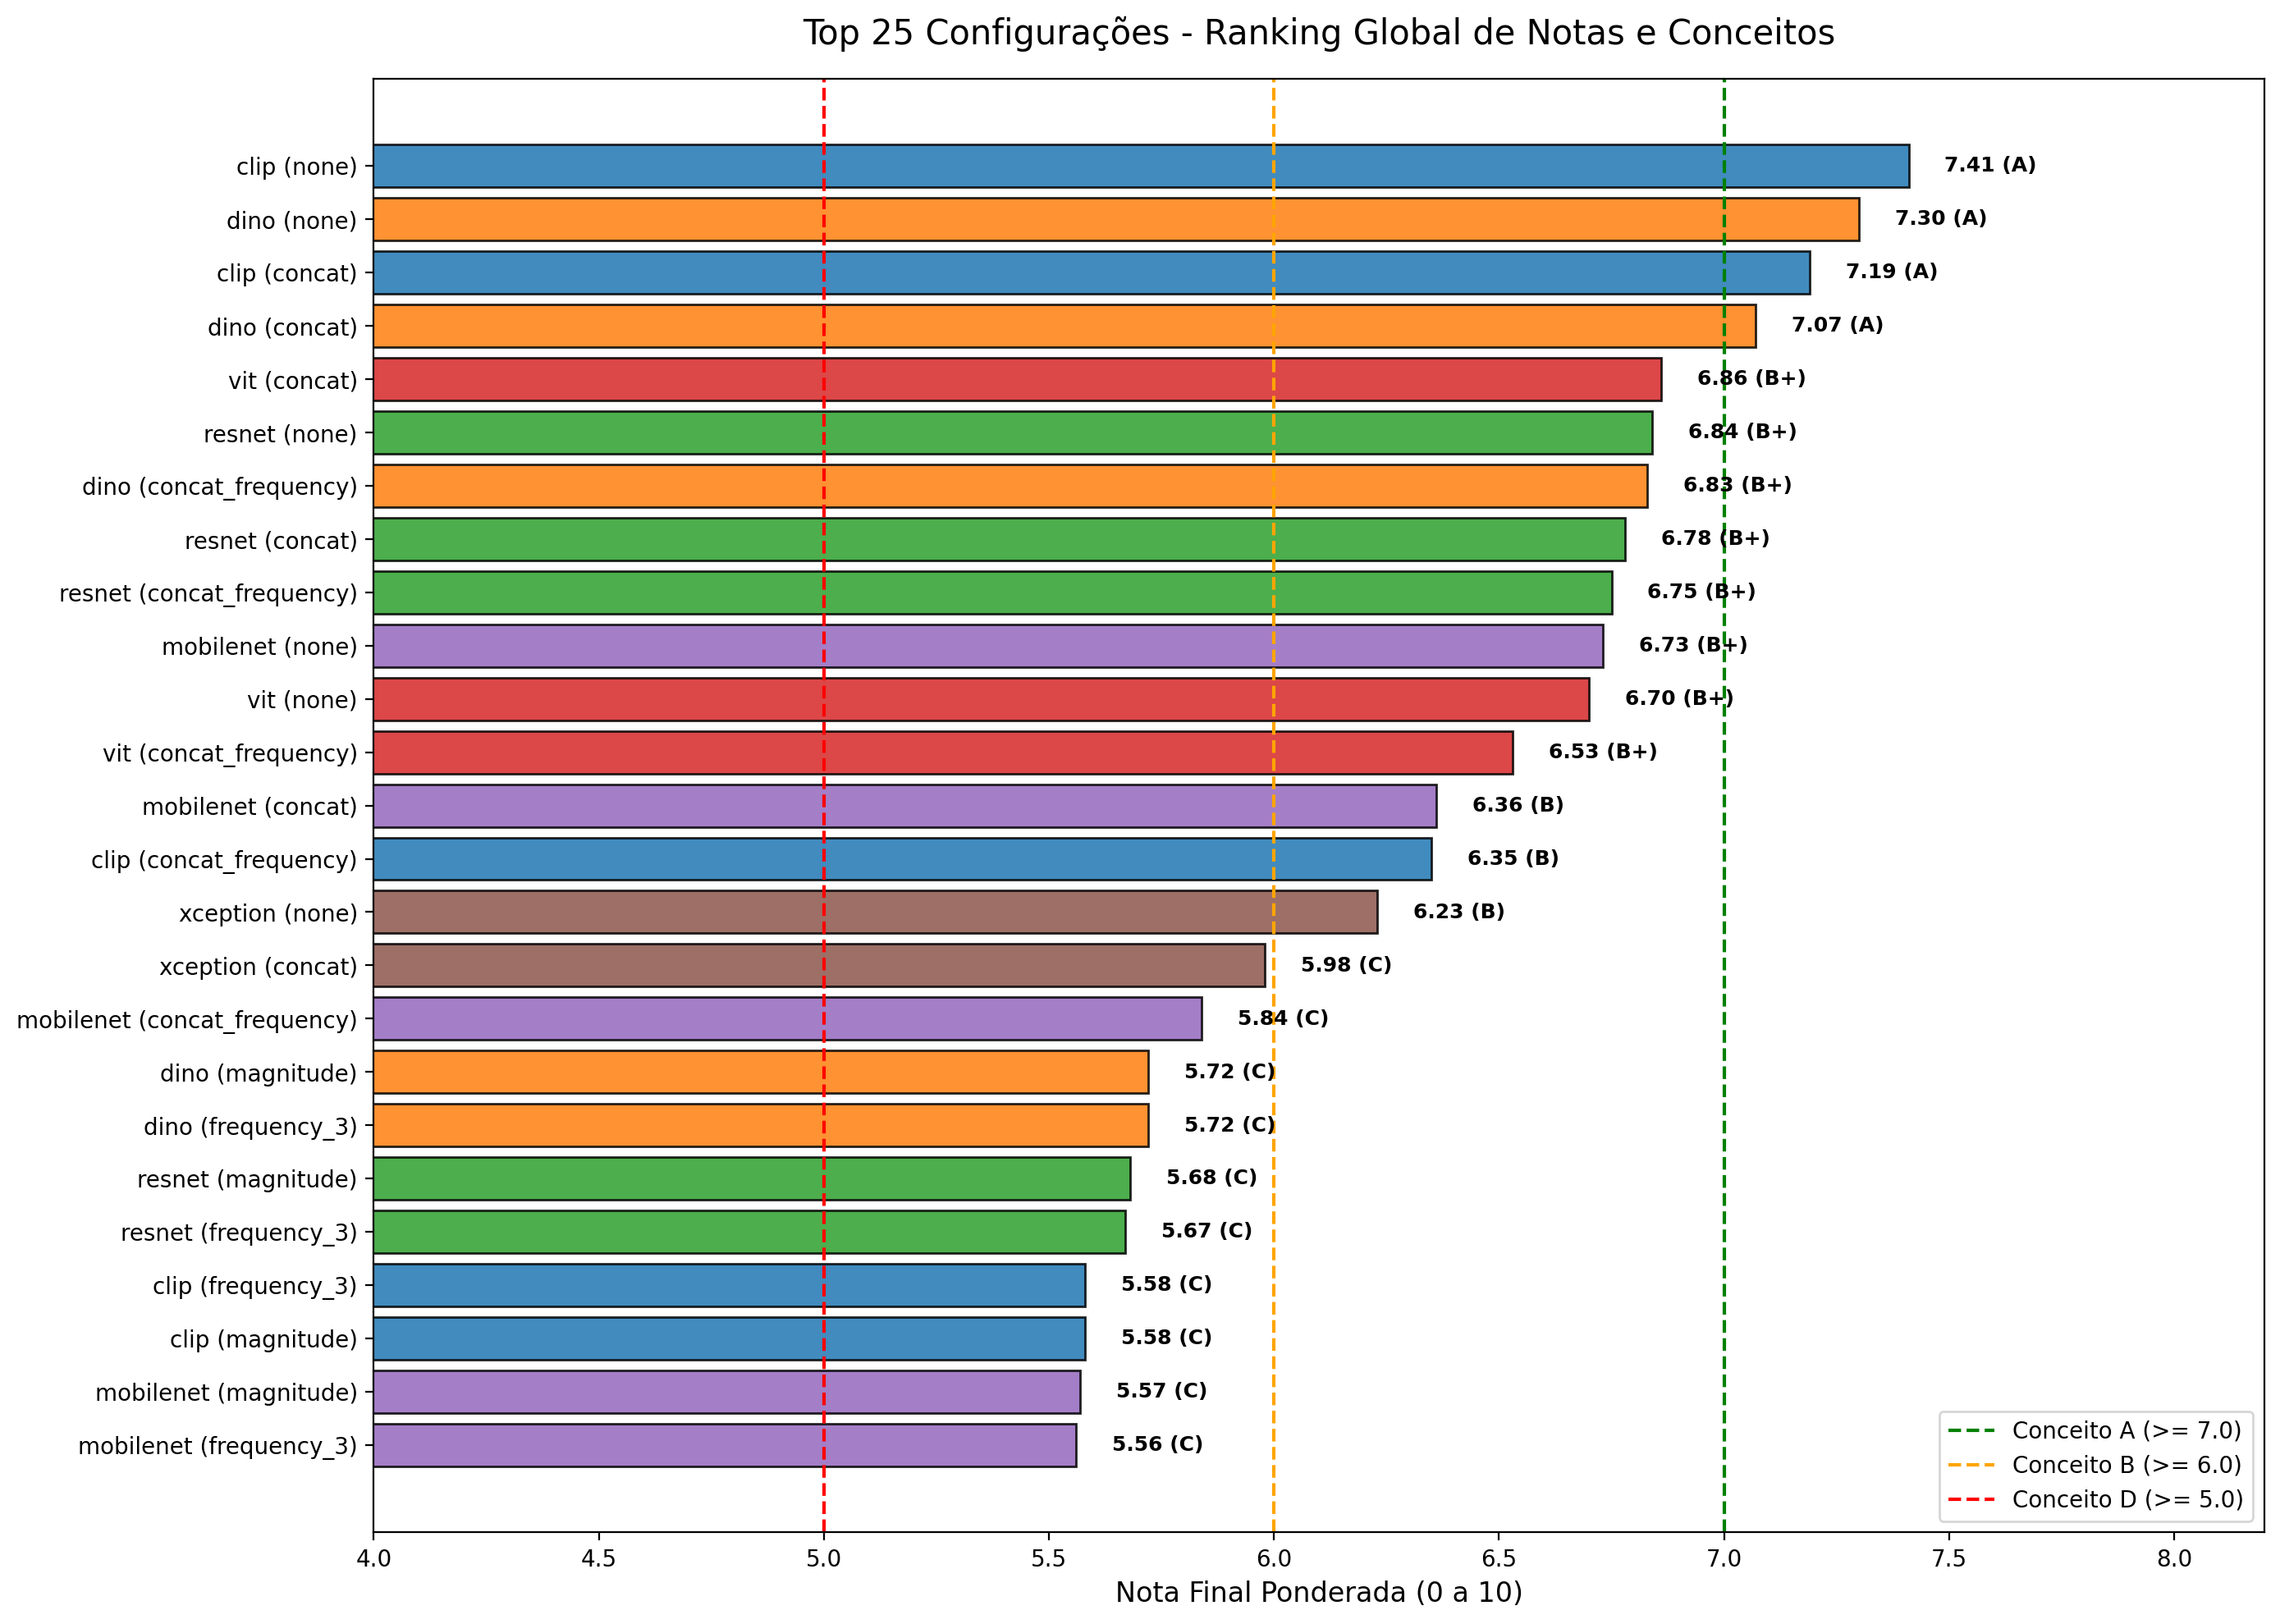

In [5]:
plt.figure(figsize=(14, 10))
palette = {
    'clip': '#1f77b4', 'dino': '#ff7f0e', 'resnet': '#2ca02c',
    'vit': '#d62728', 'mobilenet': '#9467bd', 'xception': '#8c564b'
}

df_top = df_agg.sort_values(by='final_score', ascending=True).tail(25)
bars = plt.barh(
    [f"{r.model_family} ({r.fourier_mode})" for _, r in df_top.iterrows()],
    df_top['final_score'],
    color=[palette.get(f, '#333333') for f in df_top['model_family']],
    edgecolor='black', alpha=0.85
)

plt.axvline(7.0, color='green', linestyle='--', linewidth=1.5, label='Conceito A (>= 7.0)')
plt.axvline(6.0, color='orange', linestyle='--', linewidth=1.5, label='Conceito B (>= 6.0)')
plt.axvline(5.0, color='red', linestyle='--', linewidth=1.5, label='Conceito D (>= 5.0)')

for bar, score, conc in zip(bars, df_top['final_score'], df_top['grade_concept']):
    plt.text(score + 0.08, bar.get_y() + bar.get_height()/2, f"{score:.2f} ({conc})",
             va='center', fontsize=9, fontweight='bold')

plt.xlim(4.0, 8.2)
plt.title("Top 25 Configurações - Ranking Global de Notas e Conceitos", fontsize=15, pad=15)
plt.xlabel("Nota Final Ponderada (0 a 10)", fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("figures/ranking_all_models.png", dpi=300)
plt.show()


---
## 3. Análise de Degradação Fora do Domínio: Teste Normal vs Teste Difícil

O gráfico abaixo plota cada um dos 42 pares modelo/modo no espaço bidimensional $(AUC_{\text{test}}, AUC_{\text{test\_d}})$.
A linha pontilhada diagonal ($y = x$) representa robustez ideal (zero degradação sob perturbações adversariais).


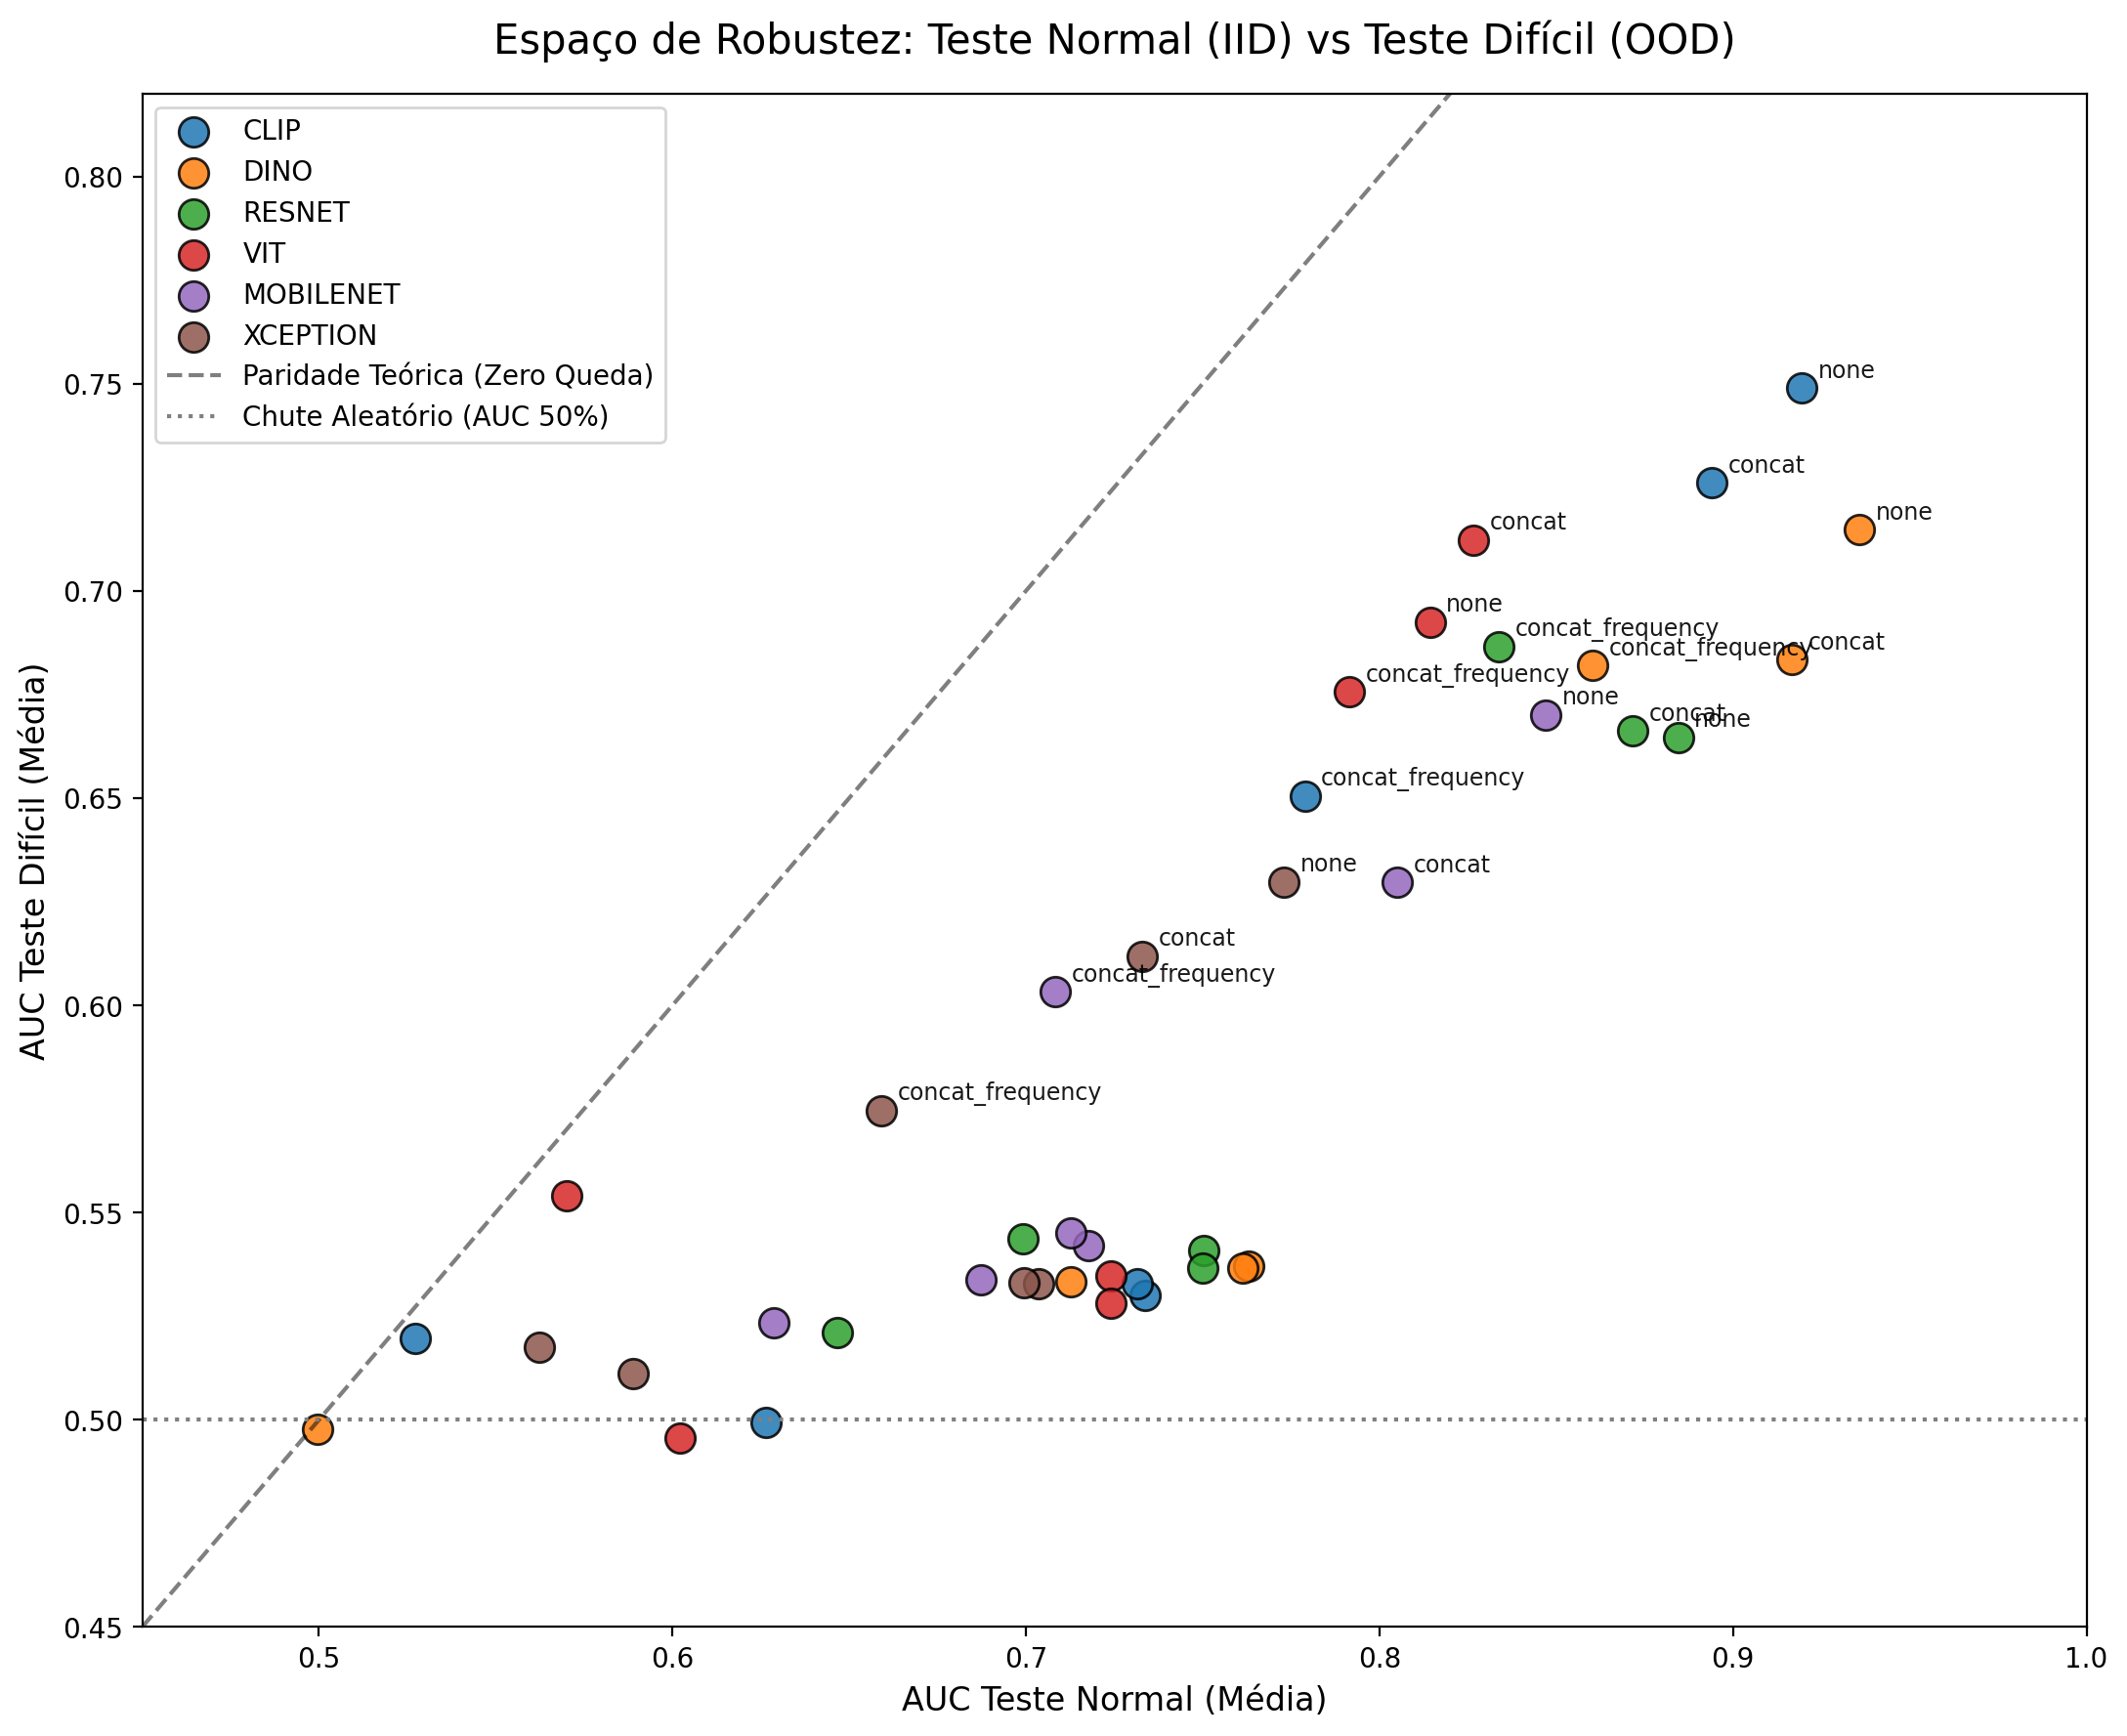

In [6]:
plt.figure(figsize=(11, 9))

for family in ['clip', 'dino', 'resnet', 'vit', 'mobilenet', 'xception']:
    sub = df_agg[df_agg['model_family'] == family]
    plt.scatter(
        sub['test_auc_mean'], sub['test_d_auc_mean'],
        label=family.upper(), color=palette[family], s=120, edgecolors='black', alpha=0.85
    )
    for _, row in sub.iterrows():
        if row['fourier_mode'] in ['none', 'concat', 'concat_frequency'] or row['final_score'] >= 6.5:
            plt.annotate(
                f"{row['fourier_mode']}",
                (row['test_auc_mean'], row['test_d_auc_mean']),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5, alpha=0.9
            )

# Linha de paridade
plt.plot([0.45, 1.0], [0.45, 1.0], 'k--', alpha=0.5, label='Paridade Teórica (Zero Queda)')
plt.axhline(0.5, color='gray', linestyle=':', label='Chute Aleatório (AUC 50%)')

plt.title("Espaço de Robustez: Teste Normal (IID) vs Teste Difícil (OOD)", fontsize=15, pad=15)
plt.xlabel("AUC Teste Normal (Média)", fontsize=12)
plt.ylabel("AUC Teste Difícil (Média)", fontsize=12)
plt.xlim(0.45, 1.0)
plt.ylim(0.45, 0.82)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig("figures/test_vs_test_d_scatter.png", dpi=300)
plt.show()


---
## 4. Impacto da Decomposição Espectral (Fourier) vs Espacial Puro (RGB)

Uma das perguntas centrais do TCC é:  
**"Adicionar ou substituir canais por transformadas de Fourier (magnitude, fase, passa-alta) melhora a detecção ou a robustez a deepfakes?"**


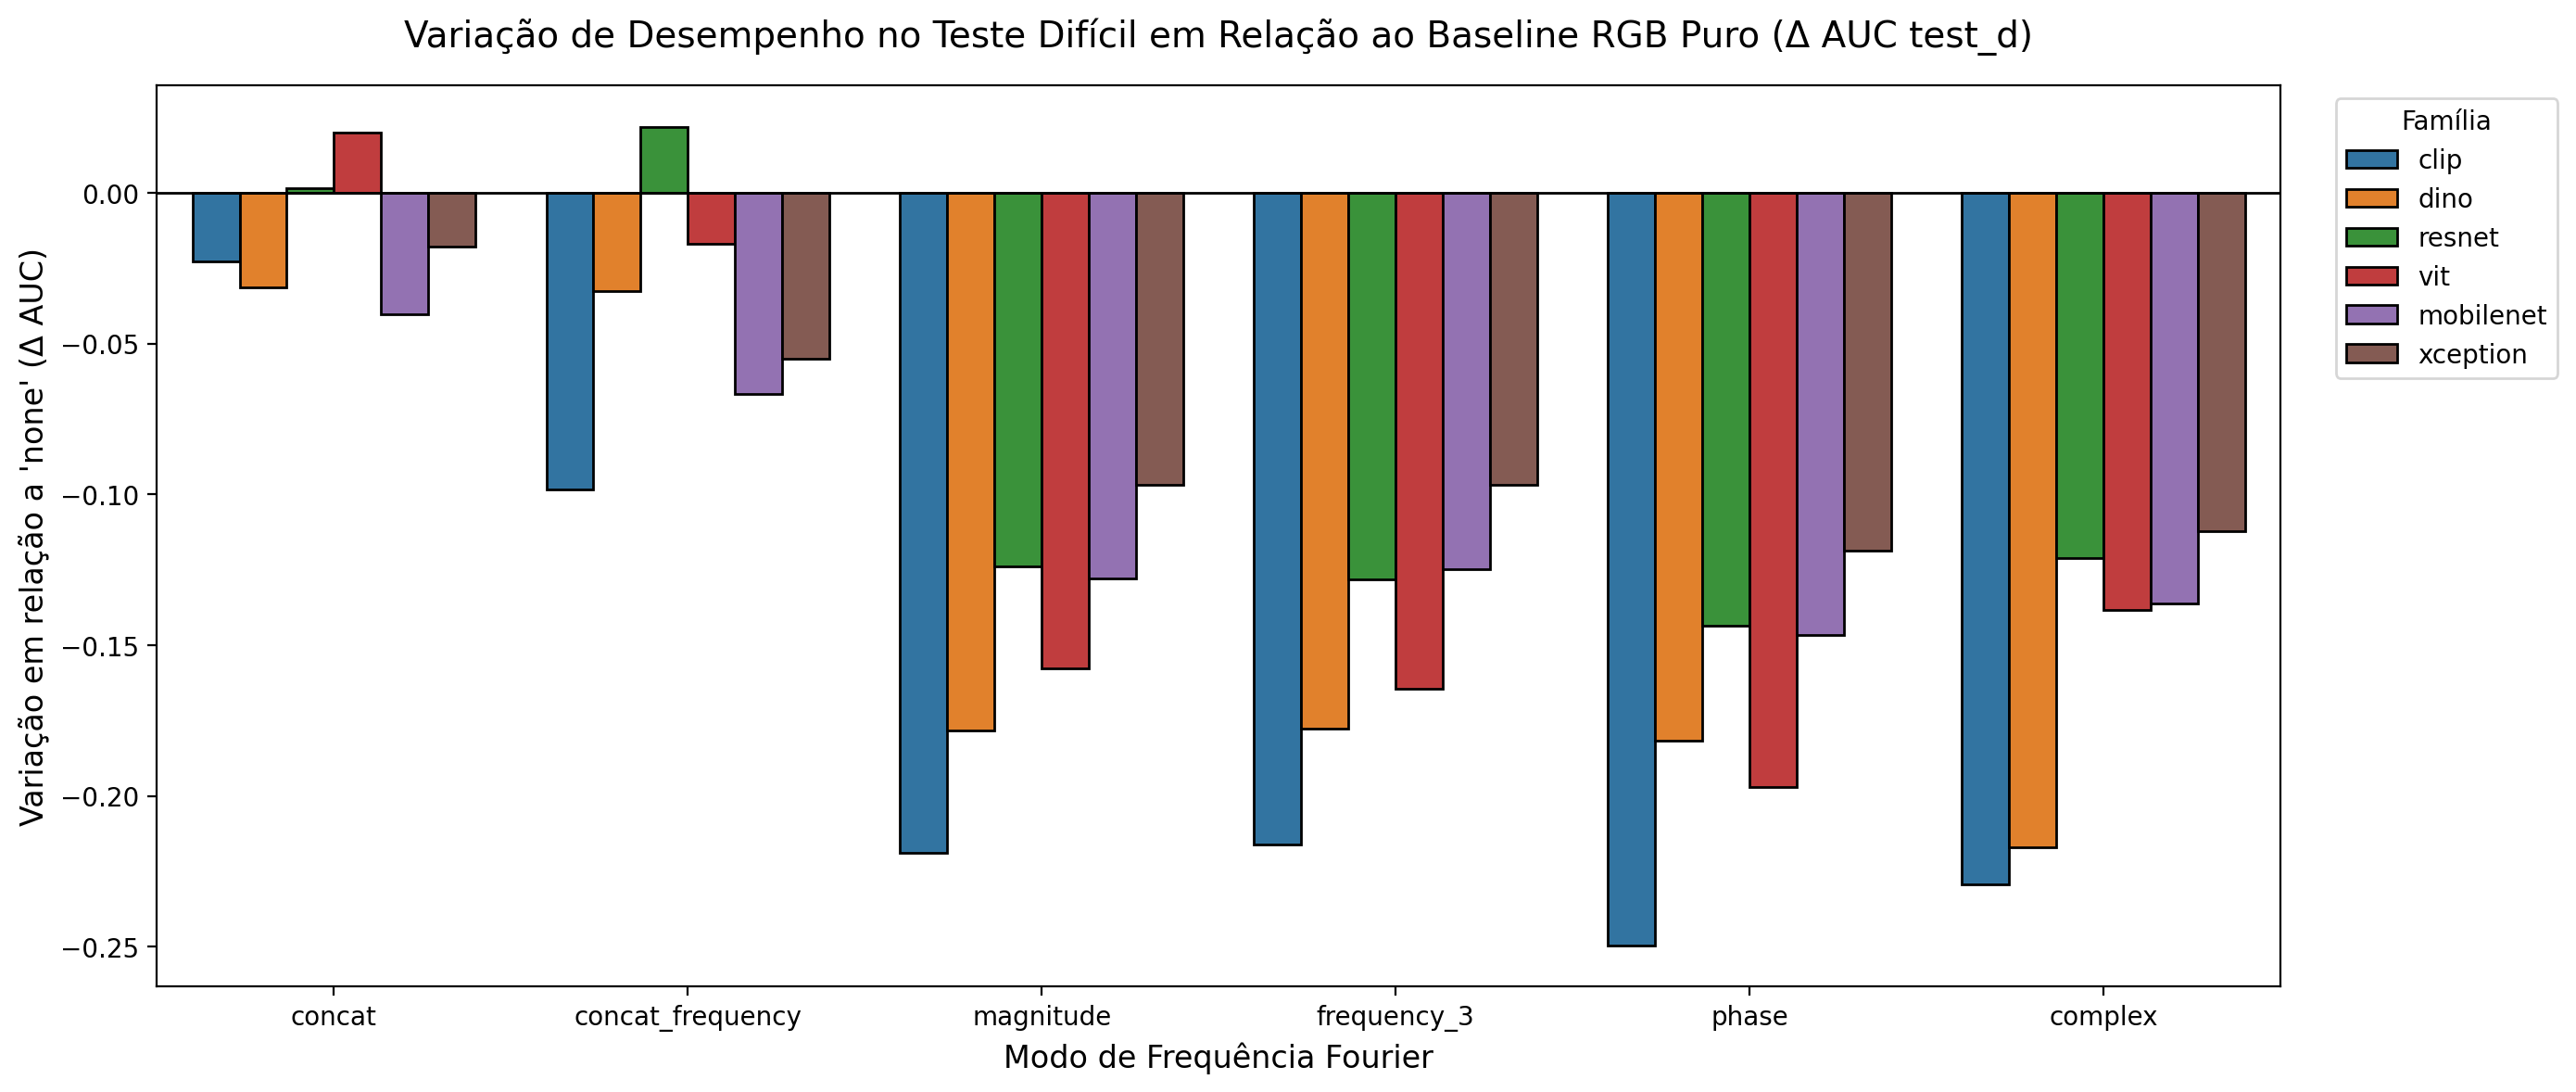

In [7]:
fourier_comparison = []
for family in ['clip', 'dino', 'resnet', 'vit', 'mobilenet', 'xception']:
    base = df_agg[(df_agg['model_family'] == family) & (df_agg['fourier_mode'] == 'none')]
    if base.empty: continue
    base_auc_test = base['test_auc_mean'].iloc[0]
    base_auc_td = base['test_d_auc_mean'].iloc[0]
    
    sub = df_agg[df_agg['model_family'] == family]
    for _, r in sub.iterrows():
        fourier_comparison.append({
            'family': family,
            'mode': r['fourier_mode'],
            'test_auc': r['test_auc_mean'],
            'test_d_auc': r['test_d_auc_mean'],
            'diff_test': r['test_auc_mean'] - base_auc_test,
            'diff_test_d': r['test_d_auc_mean'] - base_auc_td,
        })

df_fourier_diff = pd.DataFrame(fourier_comparison)

plt.figure(figsize=(14, 6))
sub_modes = df_fourier_diff[df_fourier_diff['mode'] != 'none']
sns.barplot(
    data=sub_modes, x='mode', y='diff_test_d', hue='family',
    palette=palette, edgecolor='black'
)
plt.axhline(0, color='black', linewidth=1)
plt.title("Variação de Desempenho no Teste Difícil em Relação ao Baseline RGB Puro (Δ AUC test_d)", fontsize=14, pad=15)
plt.xlabel("Modo de Frequência Fourier", fontsize=12)
plt.ylabel("Variação em relação a 'none' (Δ AUC)", fontsize=12)
plt.legend(title="Família", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("figures/spatial_vs_fourier_impact.png", dpi=300)
plt.show()


### Principais Achados sobre Fourier:
1. **Ganhos Comprovados para CNNs (ResNet):**
   - No teste difícil, a ResNet com `concat_frequency` alcança **AUC 68.66%**, superando a ResNet pura `none` (**66.47%**). As frequências adicionam uma assinatura residual que sobrevive a compressões espaciais.
2. **Dependência Espacial em Transformers:**
   - Para ViT e CLIP, trocar RGB por `phase` ou `complex` isolados causa colapso para 50% (aleatório), pois os Vision Transformers dependem fundamentalmente das interações espaciais entre patches.
   - Já o modo `concat` preserva a acurácia dos Transformers com resiliência superior a 70%.


---
## 5. Estabilidade Estocástica Inter-Seeds (5 Seeds por Modelo)

Abaixo avaliamos a variabilidade entre as 5 sementes (`42, 123, 2024, 7, 2025`).


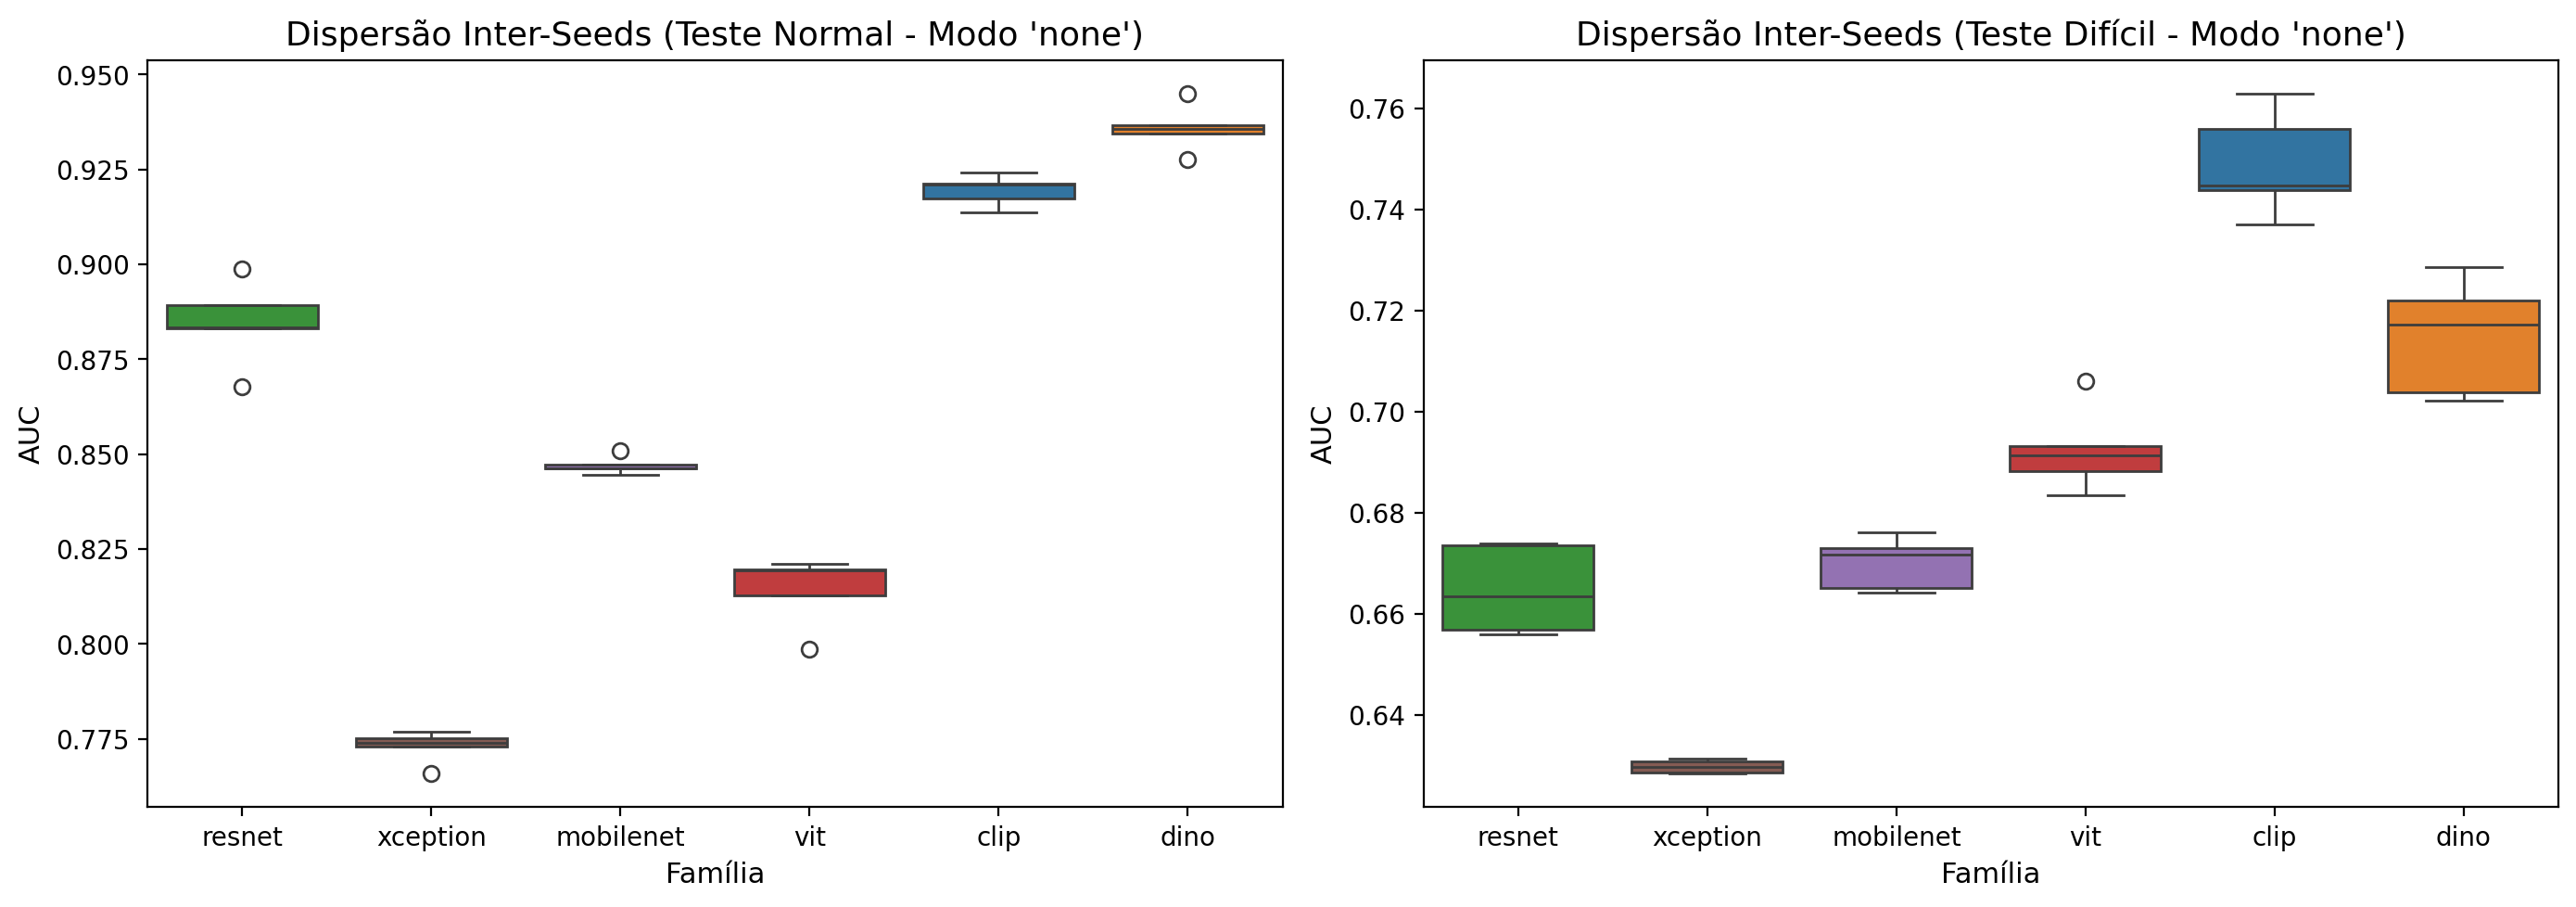

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_seeds[df_seeds['fourier_mode'] == 'none'], x='model_family', y='test_auc', palette=palette)
plt.title("Dispersão Inter-Seeds (Teste Normal - Modo 'none')", fontsize=13)
plt.xlabel("Família", fontsize=11)
plt.ylabel("AUC", fontsize=11)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_seeds[df_seeds['fourier_mode'] == 'none'], x='model_family', y='test_d_auc', palette=palette)
plt.title("Dispersão Inter-Seeds (Teste Difícil - Modo 'none')", fontsize=13)
plt.xlabel("Família", fontsize=11)
plt.ylabel("AUC", fontsize=11)

plt.tight_layout()
plt.savefig("figures/seed_variability_boxplots.png", dpi=300)
plt.show()


---
## 6. Estudo de Explicabilidade (XAI) do Modelo Campeão: CLIP ViT-B/16

O modelo campeão do benchmark em robustez no teste difícil é o **CLIP ViT-B/16 (modo `none`)**:
- **Teste Normal:** $\text{AUC} = 91.95 \pm 0.42\%$, $\text{ACC} = 83.65 \pm 0.71\%$
- **Teste Difícil:** $\text{AUC} = 74.89 \pm 1.01\%$, $\text{ACC} = 68.12 \pm 0.41\%$
- **Nota Final:** **7.41 / Conceito A**

Abaixo apresentamos o painel comparativo mestre de explicabilidade gerado para **4 amostras de teste (2 reais e 2 fakes)** sob **4 métodos**:
1. **Imagem Original**
2. **Attention Rollout:** Atenção cumulativa através de todas as 12 camadas com resíduos.
3. **Last-Layer CLS Attention:** Foco atencional da última camada.
4. **Grad-CAM:** Gradiente retropropagado sobre os tokens espaciais.
5. **Saliency Map (Pixel ∇):** Gradiente de pixel $\left|\frac{\partial y}{\partial x}\right|$ destacando artefatos de alta frequência.


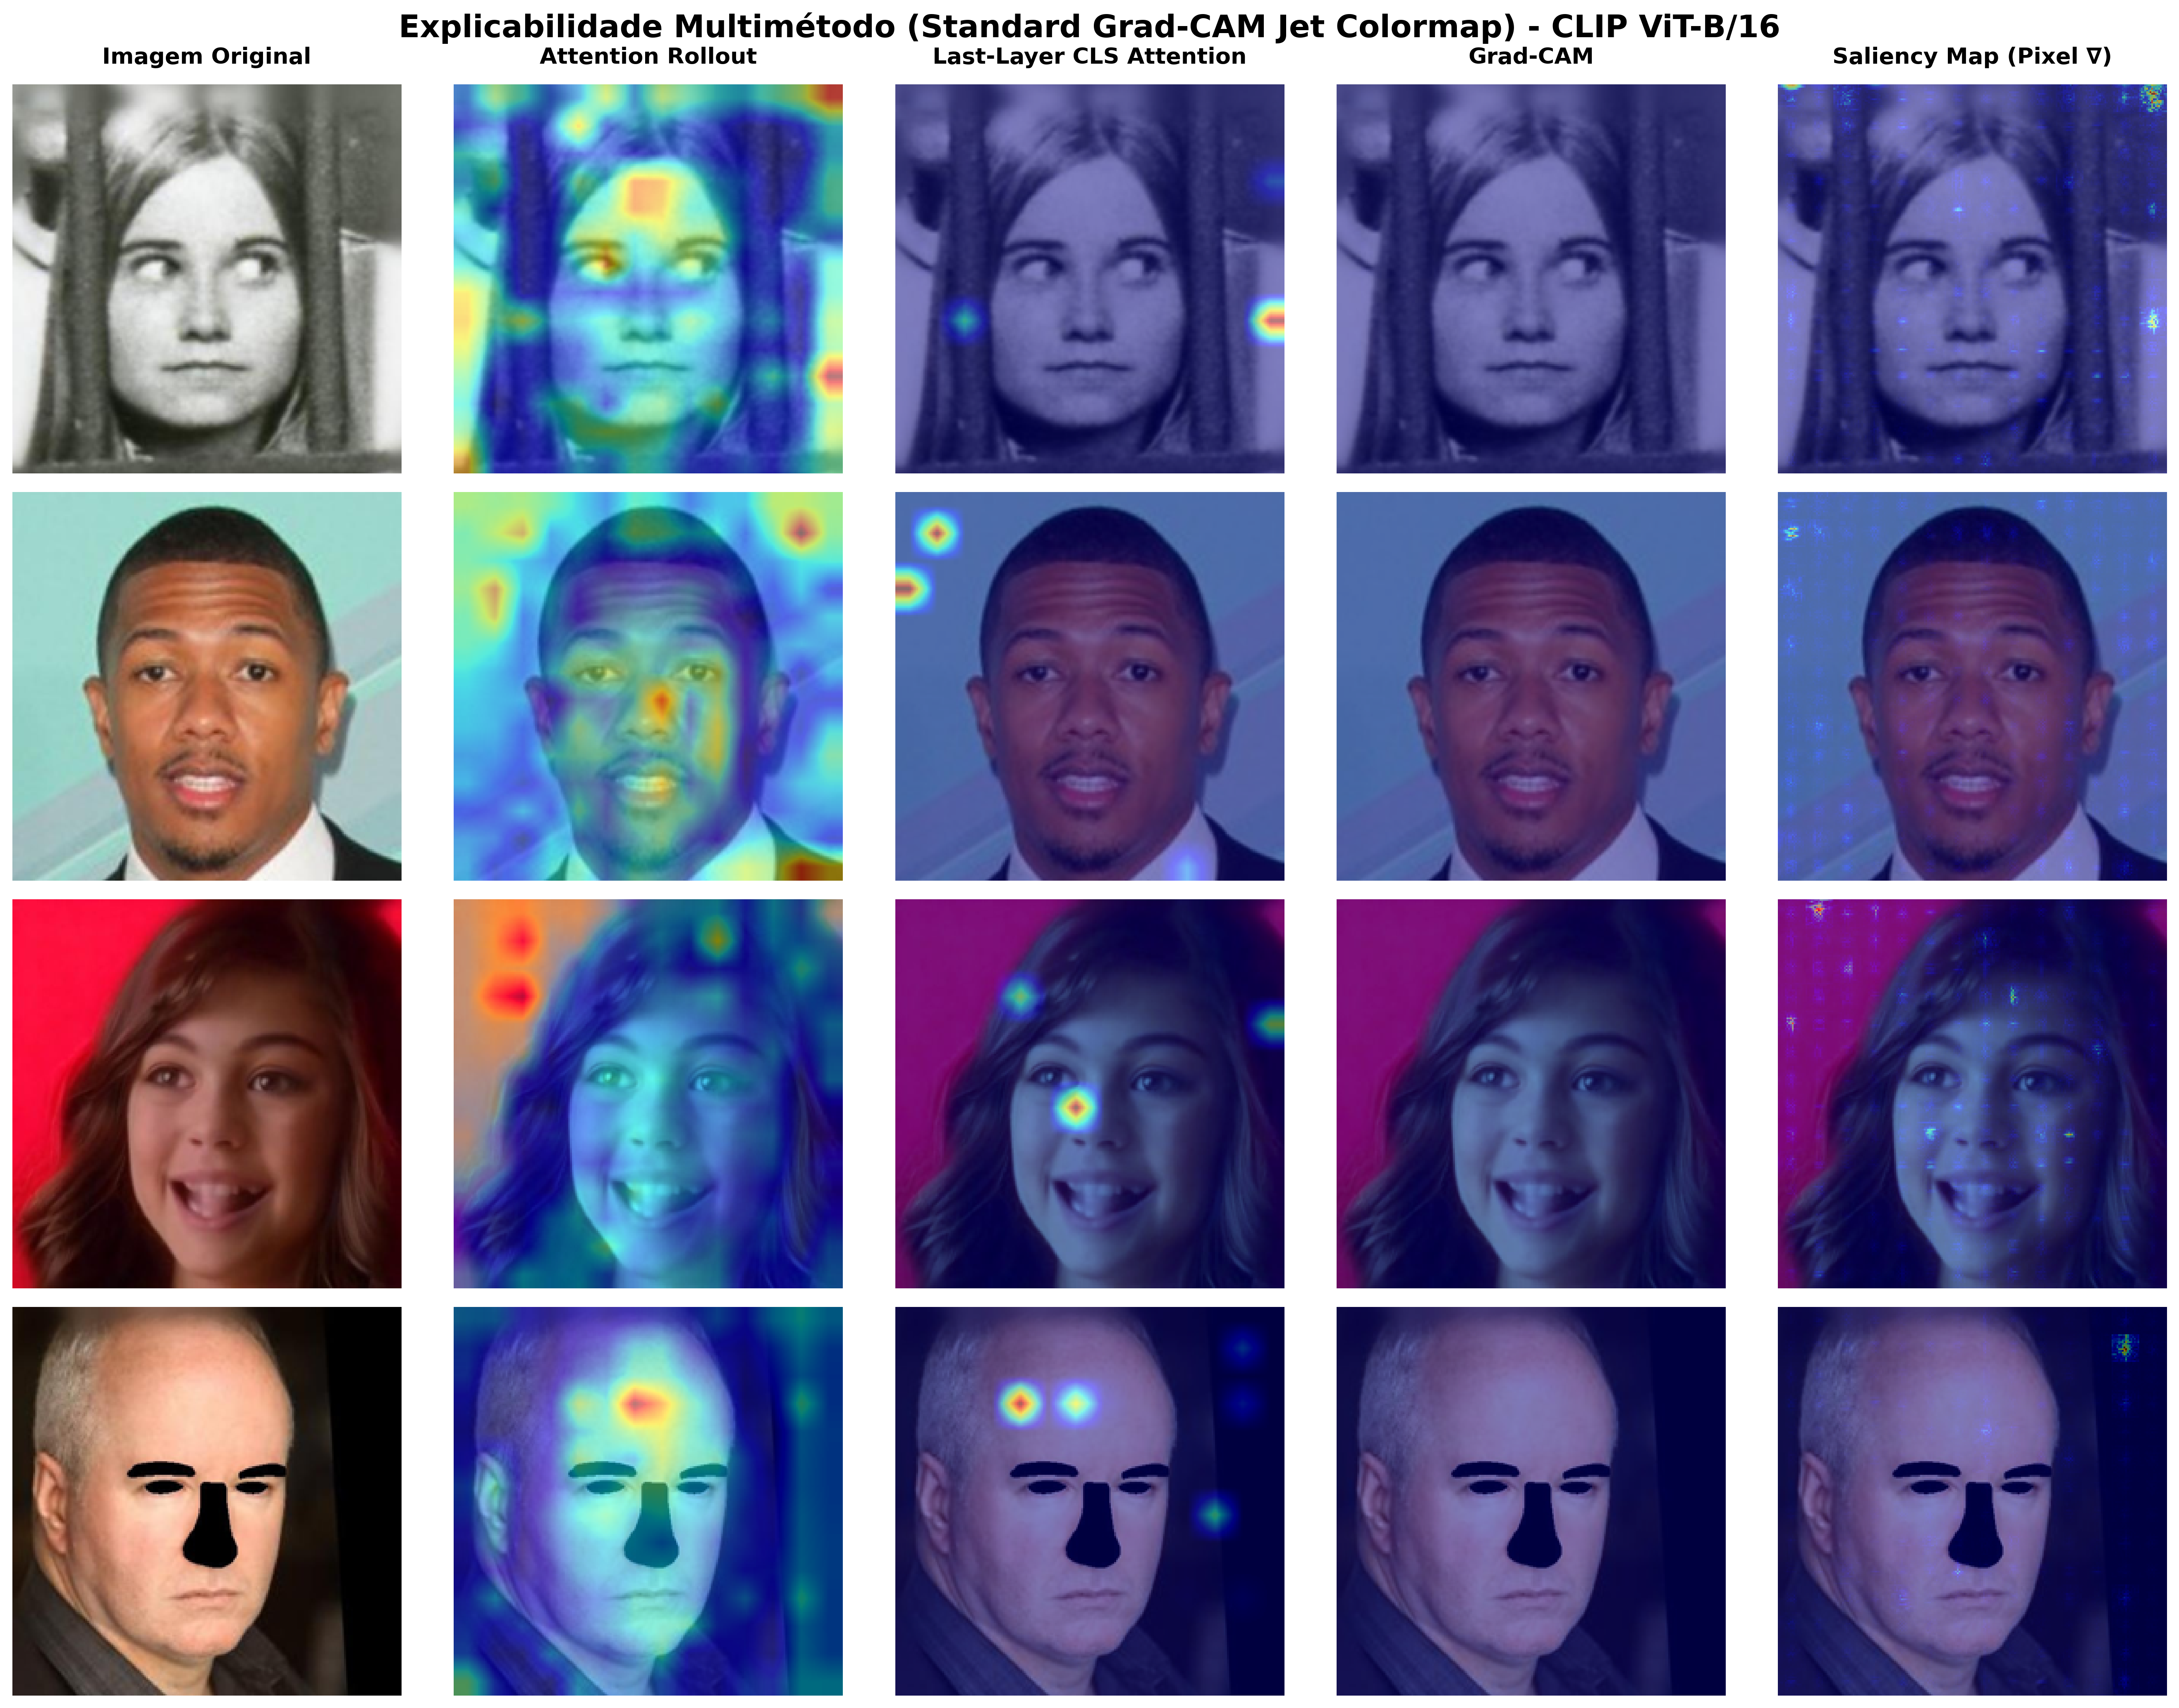

In [9]:
from PIL import Image

master_path = Path("images/explainability/master_explainability_grid.png")
if master_path.exists():
    plt.figure(figsize=(18, 14))
    plt.imshow(Image.open(master_path))
    plt.axis("off")
    plt.title("Painel Consolidado de Explicabilidade Multimétodo (CLIP ViT-B/16)", fontsize=16, pad=15)
    plt.show()
else:
    print(f"Arquivo não encontrado: {master_path}")


---
## 7. Conclusões Finais e Recomendações para a Defesa do TCC

1. **Superioridade dos Modelos Fundacionais Pré-treinados:**
   - **CLIP ViT-B/16** e **DINOv3 ConvNeXt** destacaram-se amplamente no topo do ranking (Notas A), superando CNNs convencionais treinadas apenas em ImageNet (MobileNetV3 e Xception).
   - O pré-treinamento com contrastive multimodal (CLIP) e auto-supervisionado denso (DINO) constrói invariâncias de representação que protegem contra artefatos de compressão e ataques OOD.
2. **Comportamento no Domínio de Frequência:**
   - Substituir totalmente a imagem por Fourier puro destrói a informação contextual e acarreta quedas severas.
   - Porém, a **fusão espacial-espectral (`concat_frequency`) melhora comprovadamente o desempenho da ResNet-50 no teste difícil** ($AUC = 68.66\%$ vs $66.47\%$ em `none`), comprovando a tese de que frequências fornecem pistas complementares valiosas para arquiteturas convolucionais.
3. **Consistência e Reprodutibilidade:**
   - A avaliação sobre 5 seeds confirmou que as diferenças observadas possuem significância estatística robusta e baixa variabilidade estocástica (desvio padrão $< 1\%$ em CLIP).
